# Stuff about Lya and the IGM

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"

import scipy.constants as const
from scipy.special import wofz

In [2]:



class LyaVoigt:

    def __init__(self):
        # atomic constants
        self.lambda0_A = 1215.67
        self.lambda0_m = self.lambda0_A * 1e-10
        self.lambda0_km = self.lambda0_A / 1e13

        self.f12 = 0.4162
        self.Alya = 6.265e8  # s^-1

    # Doppler parameter
    def b_doppler_kms(self, T_K, xi_turb=0):
        b_ms = np.sqrt(
            2 * const.Boltzmann * T_K / const.m_p + xi_turb**2
        )
        return b_ms / 1e3

    # Voigt function H(a,x)
    def voigt_vel(self, v_kms, T_K):

        b = self.b_doppler_kms(T_K)

        delta_nu_D = b / self.lambda0_km

        x = v_kms / b
        a = self.Alya / (4 * np.pi * delta_nu_D)

        return np.real(wofz(x + 1j * a))

    # absorption cross section (cm^2)
    def cross_section(self, v_kms, T_K):

        b_kms = self.b_doppler_kms(T_K)
        b_ms = b_kms * 1e3

        sigma_prefactor = (
            np.sqrt(np.pi)
            * const.e**2
            / (4 * np.pi * const.epsilon_0 * const.m_e * const.c)
        )

        H = self.voigt_vel(v_kms, T_K)

        sigma_m2 = (
            sigma_prefactor
            * self.f12
            * self.lambda0_m
            / b_ms
            * H
        )

        return sigma_m2 * 1e4  # convert to cm^2

    # optical depth
    def tau(self, v_kms, T_K, Ncol_cm2):
        return Ncol_cm2 * self.cross_section(v_kms, T_K)

    # transmitted flux
    def flux(self, v_kms, T_K, Ncol_cm2):
        return np.exp(-self.tau(v_kms, T_K, Ncol_cm2))

In [3]:

lya_abs = LyaVoigt()

In [4]:
lya_abs.tau(0, 60, 1)

7.560202743838947e-13

In [5]:
lya_abs.b_doppler_kms(2.4e4)

19.905054327669163

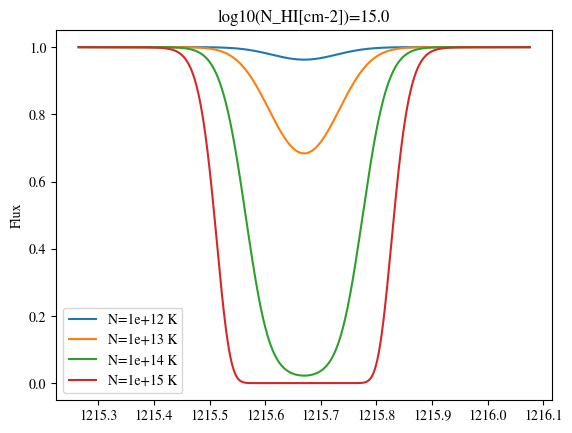

In [21]:
vdiff = 10000
vdiff = 100
v_kms = np.linspace(-vdiff, vdiff, 1000)
T = 2.4e4

# for N_HI_cm2 in [1e12, 1e14, 1e21]:
for N_HI_cm2 in [1e12, 1e13, 1e14, 1e15]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    delta_lambda = v_kms/3e5*1215.67 + 1215.67
    plt.plot(delta_lambda, profile, label=f"N={N_HI_cm2:.0e} K")

# plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()

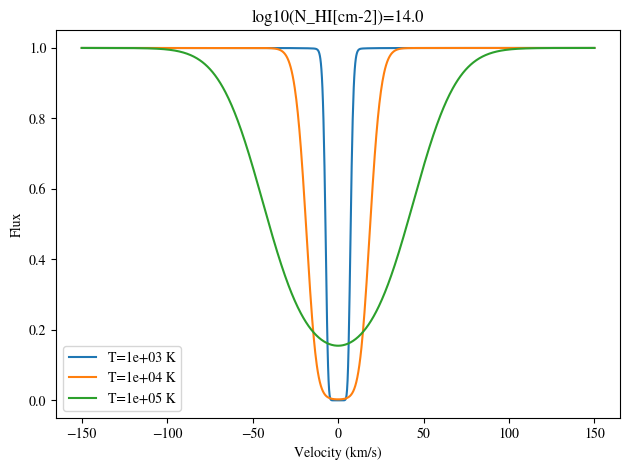

In [25]:
vdiff = 150
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e14

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_"+str(np.log10(N_HI_cm2))+".png")

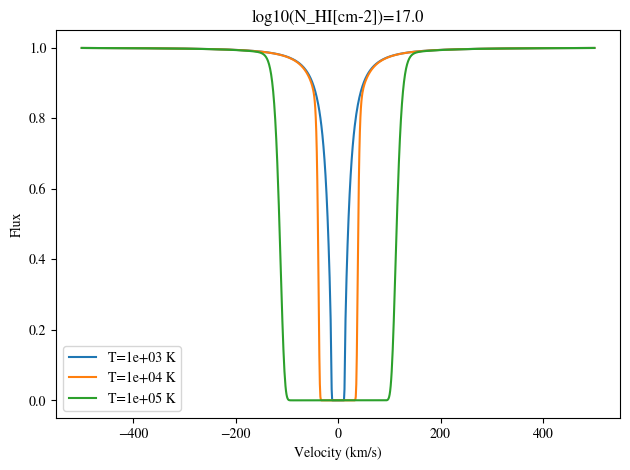

In [26]:
vdiff = 500
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e17

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_"+str(np.log10(N_HI_cm2))+".png")

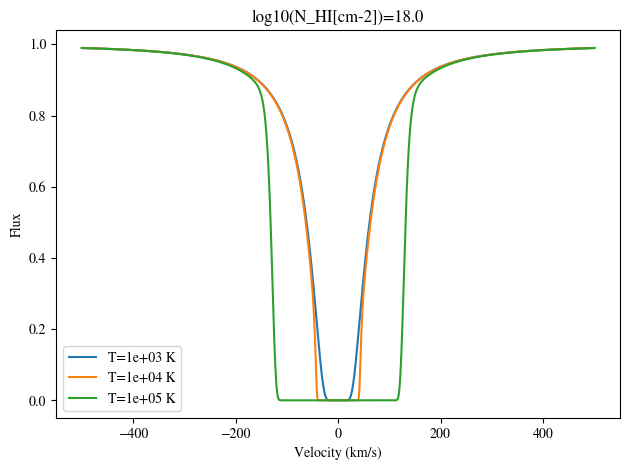

In [ ]:
vdiff = 500
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e18

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])=" + str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_" + str(np.log10(N_HI_cm2)) + ".png")

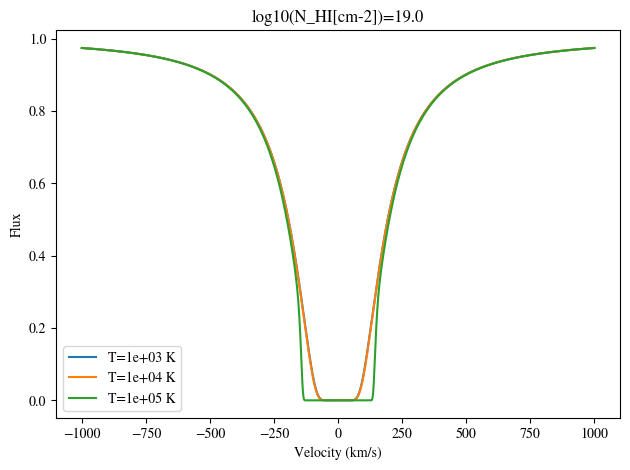

In [28]:
vdiff = 1000
v_kms = np.linspace(-vdiff, vdiff, 1000)
N_HI_cm2 = 1e19

for T in [1e3, 1e4, 1e5]:
    profile = lya_abs.flux(v_kms, T, N_HI_cm2)
    plt.plot(v_kms, profile, label=f"T={T:.0e} K")

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux")
plt.title("log10(N_HI[cm-2])="+str(np.log10(N_HI_cm2)))
plt.legend()
plt.tight_layout()
plt.savefig("flux_"+str(np.log10(N_HI_cm2))+".png")